# Multi-Modal Travel Assistant using LangGraph

### Objective

The aim of this project is to build an agentic travel assistant capable of:

- deciding between local knowledge and web search
- retrieving city information
- fetching weather forecast data
- retrieving location images
- generating structured output
- visualizing weather trends

The workflow is implemented using LangGraph with memory support.

# Cell 1 — Install Dependencies

In [82]:
!pip install langgraph langchain chromadb pandas matplotlib

# Cell 2 — Imports

In [83]:
import re
import time
import random
import pandas as pd
import matplotlib.pyplot as plt

from typing import TypedDict
from typing import List
from typing import Optional

from concurrent.futures import ThreadPoolExecutor

from IPython.display import display
from IPython.display import Image
from IPython.display import Markdown

from langchain_core.messages import HumanMessage
from langchain_core.messages import BaseMessage

from langgraph.graph import StateGraph
from langgraph.graph import END

from langgraph.checkpoint.memory import MemorySaver

import chromadb
from chromadb.utils import embedding_functions

# Cell 3 — Mock Weather and Image APIs

Real APIs were replaced with mock services so the focus remains on workflow architecture.

In [84]:
CITY_TEMPS={

"tokyo":26,
"paris":20,
"new york":18

}


def get_weather_forecast(city):

    time.sleep(1)

    base=CITY_TEMPS.get(
        city.lower(),
        23
    )

    forecast=[]

    for day in [

    "Mon",
    "Tue",
    "Wed",
    "Thu",
    "Fri",
    "Sat",
    "Sun"

    ]:

        forecast.append({

        "day":day,

        "temp_high":
        base+random.randint(1,4),

        "temp_low":
        base-random.randint(1,4),

        "condition":
        random.choice(

        [

        "Sunny",
        "Cloudy",
        "Rainy"

        ])

        })

    return forecast

In [85]:
CITY_IMAGES={

"tokyo":[

{

"url":"https://images.unsplash.com/photo-1540959733332-eab4deabeeaf?w=800",

"description":
"Shibuya crossing at night"

},

{

"url":"https://images.unsplash.com/photo-1528164344705-47542687000d?w=800",

"description":
"Cherry blossom park in Tokyo"

}

],


"paris":[

{

"url":"https://images.unsplash.com/photo-1502602898657-3e91760cbb34?w=800",

"description":
"Eiffel Tower during daytime"

}

],


"default":[

{

"url":"https://images.unsplash.com/photo-1506744038136-46273834b3fb?w=800",

"description":
"Popular tourist location"

}

]

}


def get_city_images(city):

    time.sleep(.5)

    return CITY_IMAGES.get(

    city.lower(),

    CITY_IMAGES["default"]

    )

# Cell 4 — Mock Web Search

In [86]:
def mock_web_search(city):

    time.sleep(1)

    return f"""

    {city} is a popular tourist location.

    Information generated using
    mock search API.

    """

# Cell 5 - Local Knowledge Base

In [87]:
cities={

"Tokyo":
"""
Tokyo is Japan's capital city.

Known for technology,
anime and food culture.
""",

"Paris":
"""
Paris is famous for
the Eiffel Tower.
""",

"New York":
"""
New York is known
for Times Square.
"""

}

# Cell 6 — Create ChromaDB

In [88]:
client=chromadb.Client()

ef=embedding_functions.DefaultEmbeddingFunction()

collection=client.get_or_create_collection(

name="cities",

embedding_function=ef

)


for city,text in cities.items():

    collection.add(

    documents=[text],

    ids=[city]

    )

# Cell 7 — Query Function

In [107]:
def query_city(city):

    result = collection.query(

        query_texts=[city],

        n_results=1

    )

    returned_id = result["ids"][0][0]


    # exact city match only
    if returned_id.lower() == city.lower():

        return(

            result["documents"][0][0],

            True

        )


    return "",False

# Cell 8 — State Definition

In [108]:
class TravelState(
TypedDict,
total=False
):

    messages:List[BaseMessage]

    city:str

    source:str

    city_summary:str

    weather_forecast: List[dict]

    image_urls: List[dict]

    final_output: Optional[dict]

    error:str

# Cell 9 — Extract City Node

In [109]:
def extract_city_node(state):

    msg=state[
    "messages"
    ][-1].content


    patterns=[

    r"about\s+([A-Za-z ]+)",

    r"in\s+([A-Za-z ]+)"

    ]

    city=None

    for p in patterns:

        m=re.search(
        p,
        msg,
        re.I
        )

        if m:

            city=m.group(1)

            break


    if city is None:

        city=msg


    return{

    "city":
    city.strip().title()

    }

# Cell 10 — Router Node

In [110]:
def router_node(state):

    summary, found = query_city(
    state["city"]
    )


    if found:

        return{

        "source":
        "vector_store",

        "city_summary":
        summary

        }


    return{

    "source":
    "web_search"

    }

# Cell 11 — Web Node

In [111]:
def web_node(state):

    return{

    "city_summary":

    mock_web_search(
    state["city"]
    )

    }

# Cell 12 — Parallel Fetch Node

In [112]:
def parallel_fetch_node(state):


    with ThreadPoolExecutor(
    max_workers=2
    ) as executor:


        weather_future=\
        executor.submit(

        get_weather_forecast,

        state["city"]

        )


        image_future=\
        executor.submit(

        get_city_images,

        state["city"]

        )


    return{

    "weather_forecast":
    weather_future.result(),

    "image_urls":
    image_future.result()

    }

# Cell 13 — Merge Node

In [113]:
def merge_node(state):

    return{

    "final_output":{

    "city_summary":

    state.get(
    "city_summary",""
    ),

    "weather_forecast":

    state.get(
    "weather_forecast",[]
    ),

    "image_urls":

    state.get(
    "image_urls",[]
    )

    }

    }

# Cell 14 — Routing Function

In [114]:
def route(state):

    return state["source"]

# Cell 15 — Build Graph

In [115]:
builder=StateGraph(
TravelState
)

builder.add_node(
"extract",
extract_city_node
)

builder.add_node(
"router",
router_node
)

builder.add_node(
"web",
web_node
)

builder.add_node(
"parallel",
parallel_fetch_node
)

builder.add_node(
"merge",
merge_node
)

builder.set_entry_point(
"extract"
)

builder.add_edge(
"extract",
"router"
)


builder.add_conditional_edges(

"router",

route,

{

"vector_store":
"parallel",

"web_search":
"web"

}

)


builder.add_edge(
"web",
"parallel"
)

builder.add_edge(
"parallel",
"merge"
)

builder.add_edge(
"merge",
END
)

# Cell 16 — Compile Graph

In [116]:
memory=MemorySaver()

graph=builder.compile(

checkpointer=
memory
)

# Cell 17 — Run Examples

Example 1

In [117]:
start=time.time()

result=graph.invoke(

{

"messages":[

HumanMessage(

content=
"Tell me about Tokyo"

)

]

},

config={

"configurable":{

"thread_id":
"travel_demo"

}

}

)

print(
"Source: ", result["source"]
)

end=time.time()

print(
f"Execution Time:{end-start:.2f} sec"
)

Source:  vector_store
Execution Time:1.37 sec


Example 2

In [119]:
start=time.time()

result2=graph.invoke(

{

"messages":[

HumanMessage(

content=
"Tell me about Snohomish"

)

]

},

config={

"configurable":{

"thread_id":"2"

}

}

)

print(
"Source: ", result2["source"]
)

end=time.time()

print(
f"Execution Time:{end-start:.2f} sec"
)

Source:  web_search
Execution Time:2.74 sec


# Cell 18 — View Output

In [101]:
result["final_output"]

{'city_summary': "\nTokyo is Japan's capital city.\n\nKnown for technology,\nanime and food culture.\n",
 'weather_forecast': [{'day': 'Mon',
   'temp_high': 27,
   'temp_low': 25,
   'condition': 'Sunny'},
  {'day': 'Tue', 'temp_high': 27, 'temp_low': 23, 'condition': 'Cloudy'},
  {'day': 'Wed', 'temp_high': 29, 'temp_low': 24, 'condition': 'Cloudy'},
  {'day': 'Thu', 'temp_high': 30, 'temp_low': 24, 'condition': 'Cloudy'},
  {'day': 'Fri', 'temp_high': 30, 'temp_low': 22, 'condition': 'Sunny'},
  {'day': 'Sat', 'temp_high': 29, 'temp_low': 23, 'condition': 'Rainy'},
  {'day': 'Sun', 'temp_high': 30, 'temp_low': 24, 'condition': 'Cloudy'}],
 'image_urls': [{'url': 'https://images.unsplash.com/photo-1540959733332-eab4deabeeaf?w=800',
   'description': 'Shibuya crossing at night'},
  {'url': 'https://images.unsplash.com/photo-1528164344705-47542687000d?w=800',
   'description': 'Cherry blossom park in Tokyo'}]}

# Cell 19 — Weather Chart

In [102]:
df=pd.DataFrame(

result["final_output"]
["weather_forecast"]

)

df

,day,temp_high,temp_low,condition
0,Mon,27,25,Sunny
1,Tue,27,23,Cloudy
2,Wed,29,24,Cloudy
3,Thu,30,24,Cloudy
4,Fri,30,22,Sunny
5,Sat,29,23,Rainy
6,Sun,30,24,Cloudy


# Cell 20 — Plot Weather

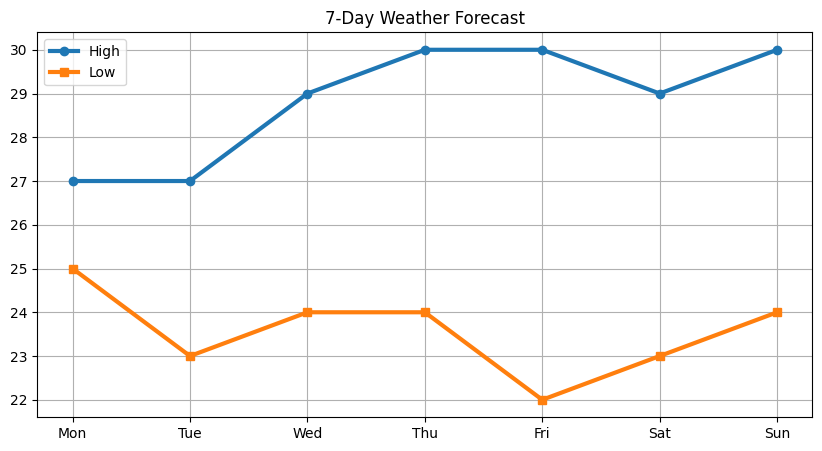


### Weather Analysis

- The plot shows predicted **high and low temperatures over the next 7 days**.
- Average daytime temperature is approximately **28.9°C**.
- Average nighttime temperature is approximately **23.6°C**.
- The warmest day appears to be **Thu**.
- The coolest night appears to be **Fri**


In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    df["day"],
    df["temp_high"],
    marker="o",
    linewidth=3,
    label="High"
)

plt.plot(
    df["day"],
    df["temp_low"],
    marker="s",
    linewidth=3,
    label="Low"
)

plt.grid()

plt.legend()

plt.title(
"7-Day Weather Forecast"
)

plt.show()

# generate simple observations
avg_high=df["temp_high"].mean()
avg_low=df["temp_low"].mean()

max_day=df.loc[
    df["temp_high"].idxmax(),
    "day"
]

min_day=df.loc[
    df["temp_low"].idxmin(),
    "day"
]

display(
Markdown(
f"""
### Weather Analysis

- The plot shows predicted **high and low temperatures over the next 7 days**.
- Average daytime temperature is approximately **{avg_high:.1f}°C**.
- Average nighttime temperature is approximately **{avg_low:.1f}°C**.
- The warmest day appears to be **{max_day}**.
- The coolest night appears to be **{min_day}**
"""
)
)

# Cell 21 — Display Images

In [104]:
for i,img in enumerate(

result[
"final_output"
]["image_urls"]

):


    display(

    Markdown(

f"""

### Image {i+1}

Description:

{img["description"]}

"""

)

)


    display(

    Image(

    url=img["url"],

    width=500

    )

    )



### Image 1

Description:

Shibuya crossing at night





### Image 2

Description:

Cherry blossom park in Tokyo



# Cell 22 — Save Graph

In [105]:
img=graph.get_graph().draw_mermaid_png()

with open(

"graph.png",

"wb"

) as f:

    f.write(img)

# Cell 23 - Display Graph

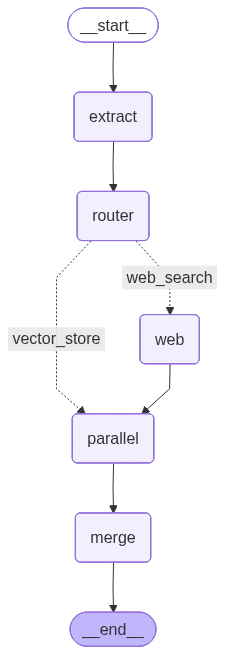

In [106]:
display(
Image(
filename="graph.png"
)
)

## LangGraph Workflow Architecture

The workflow starts by receiving a user query such as *"Tell me about Tokyo"*.

1. **Extract Node**
   - The input query is processed and the city name is extracted.

2. **Router Node**
   - The system checks whether information about the city already exists in the local vector database.
   - If available, it follows the **Vector Store path**. (ex. Tokyo)
   - Otherwise, it switches to the **Mock Web Search path**. (ex. Snohomish)

3. **Web Search (if needed)**
   - For cities not present in local knowledge, a mock search API generates a summary.

4. **Parallel Fetch Node**
   - Weather information and city images are independent tasks.
   - To reduce latency, both are fetched simultaneously using `ThreadPoolExecutor`.
   - This acts as a parallel fan-out stage.

5. **Merge Node**
   - Information from all sources is combined into a structured output containing:
     - `city_summary`
     - `weather_forecast`
     - `image_urls`

6. **Final Output**
   - The structured result is displayed using:
     - text summary
     - weather visualization
     - image gallery
     - routing explanation

This design demonstrates conditional routing, multi-modal data integration, parallel execution, and memory-based workflow orchestration using LangGraph.

---